### WRF Rainfall Rate Handling and Plotting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import netCDF4 as nc
from netCDF4 import Dataset
import mask_tc
from matplotlib.dates import date2num
from matplotlib.patches import Patch
import matplotlib.dates as mdates
import os

### Helper Functions

In [2]:
def runname_prefix(run):
    if run == 'control':
        return 'c'
    elif run == 'diurnal':
        return 'd'
    elif run == 'c_imp1':
        return 'cimp'
    elif run == 'd_imp1':
        return 'dimp'
    elif run == 'd_imp2':
        return 'dimp2'
    elif run == 'c_imp2':
        return 'cimp2'
    elif run == 'nocrf':
        return 'nocrf'
    elif run == 'nocrfimp':
        return 'nocrfimp'
    return run

In [3]:
import numpy as np
from scipy.signal import correlate

def compute_cross_correlation_lag(series1, series2, times=None):
    """
    Computes the lag in hours between two time series using cross-correlation.
    Returns the lag in hours, and the correlation array for plotting if desired.
    """
    # Ensure NaNs don't interfere
    valid_idx = ~np.isnan(series1) & ~np.isnan(series2)
    s1 = series1[valid_idx]
    s2 = series2[valid_idx]

    if len(s1) != len(s2):
        raise ValueError("Input series must have the same length after NaN removal.")

    n = len(s1)
    corr = correlate(s2 - np.mean(s2), s1 - np.mean(s1), mode='full')
    lags = np.arange(-n + 1, n)
    lag_hours = lags[np.argmax(corr)]

    return lag_hours, corr, lags

In [6]:
def plot_rainrate_with_boxplot(
    runnamelist,
    trackfiles,
    directories,
    start_time='2007-08-17 21:00:00',
    box_start='2007-08-18 00:00:00',
    box_end='2007-08-20 00:00:00',
    add_boxplot=True,
    savepath='rainrate_plot.png',
    rmax=2,
    colors=None,
    linestyles=None,
    mask=True
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from netCDF4 import Dataset

    # Handle color and linestyle defaults
    default_colors = sns.color_palette('tab10', len(runnamelist))
    color_dict = {run: default_colors[i] for i, run in enumerate(runnamelist)} if colors is None else colors
    linestyle_dict = {run: '-' for run in runnamelist} if linestyles is None else linestyles

    all_stats = []
    time_len = None

    for run, directory in zip(runnamelist, directories):
        with Dataset(directory, 'r') as nc:
            rainc = nc.variables['RAINC'][:]
            rainnc = nc.variables['RAINNC'][:]
            precip = rainc + rainnc  # shape (time, y, x)

        # Reshape to (time, 1, y, x) so it's compatible with masking
        precip = precip[:, np.newaxis, :, :]  # (61, 1, 1050, 1070)

        if mask:
            masked_precip = mask_tc.mask_tc_track(trackfiles[run], rmax, precip, lon, lat, 0, precip.shape[0])
        else:
            masked_precip = precip

        # Difference across time to get 1-hourly rain (shape will be 60 instead of 61)
        hourly_rain = masked_precip[1:, :, :, :] - masked_precip[:-1, :, :, :]

        # Mask zeroes and compute mean rain rate for each hour
        hourly_rain = np.ma.masked_equal(hourly_rain, 0)
        avg_rainrate = np.mean(hourly_rain[:, 0, :, :], axis=(1, 2))

        all_stats.append(avg_rainrate)

        if time_len is None:
            time_len = avg_rainrate.shape[0]
    #Correlation Calculation
    if len(runnamelist) == 2:
        times = pd.date_range(start=start_time, periods=time_len, freq='H')
        lag, corr_vals, lags = compute_cross_correlation_lag(all_stats[0], all_stats[1], times)
        print(f"Max correlation occurs at a lag of {lag} hours")

    # Create hourly time array starting from user-specified string
    times = pd.date_range(start=start_time, periods=time_len, freq='H')

    # Determine boxplot time indices
    box_start = pd.Timestamp(box_start)
    box_end = pd.Timestamp(box_end)
    box_idxs = [i for i, t in enumerate(times) if box_start <= t <= box_end]
    print("color_dict:", color_dict)
    print("linestyle_dict:", linestyle_dict)
    print("runnamelist:", runnamelist)
    print("all_stats type:", type(all_stats))
    print("all_stats[i] type:", type(all_stats[0]))

    # === Figure setup ===
    if add_boxplot:
        fig, (ts_ax, box_ax) = plt.subplots(
            1, 2, figsize=(12, 5),
            width_ratios=[0.7, 0.3],
            layout='constrained'
        )
    else:
        fig, ts_ax = plt.subplots(figsize=(12, 5), layout='constrained')
        box_ax = None

    # === Time series plot ===
    for i, run in enumerate(runnamelist):
        ts_ax.plot(
            times, all_stats[i],
            label=run,
            color=color_dict[run],
            linestyle=linestyle_dict[run],
            linewidth=1.6
        )

    ts_ax.set_title('Average Hourly Rainfall Rate for TS Erin', fontsize=12, fontweight='bold')
    ts_ax.set_xlabel('Date and Time (UTC)', fontsize=10)
    ts_ax.set_ylabel('Rainfall Rate (mm hr⁻¹)', fontsize=10)
    ts_ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n%HZ'))
    ts_ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ts_ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.6)

    # === Shaded nighttime periods ===
    def shade_nighttime(ax, times, offset_hours=0, color='gray', alpha=0.2):
        """Shade approximate nighttime intervals."""
        start_day = pd.Timestamp(times[0])
        end_day = pd.Timestamp(times[-1])
        current_day = start_day

        # Define sunrise/sunset (UTC-based)
        utc_sunrise = 12  # 7 AM CDT
        utc_sunset = 25   # 8 PM CDT (01 UTC next day)

        while current_day < end_day:
            night_start = current_day + pd.Timedelta(hours=(utc_sunset + offset_hours - 24))
            night_end = current_day + pd.Timedelta(hours=(utc_sunrise + offset_hours))
            if night_start < times[-1] and night_end > times[0]:
                ax.axvspan(night_start, night_end, color=color, alpha=alpha, lw=0)
            current_day += pd.Timedelta(days=1)

    # Apply night shading for both control and diurnal runs
    shade_nighttime(ts_ax, times, offset_hours=0, color='gray', alpha=0.15)   # Control
    shade_nighttime(ts_ax, times, offset_hours=12, color='beige', alpha=0.45) # Diurnal

    # === Legend ===
    handles, labels = ts_ax.get_legend_handles_labels()
    handles.extend([
        Patch(facecolor='gray', alpha=0.15, label='control night'),
        Patch(facecolor='beige', alpha=0.45, label='diurnal night')
    ])
    ts_ax.legend(
        handles=handles,
        loc='upper left',
        fontsize=9,
        frameon=True,
        edgecolor='black'
    )

    # === Boxplot for selected interval ===
    if add_boxplot and box_ax:
        subset_data = [all_stats[i][box_idxs] for i in range(len(runnamelist))]
        df = pd.DataFrame({
            runnamelist[i]: subset_data[i] for i in range(len(runnamelist))
        })
        df_melted = df.melt(var_name='Simulation', value_name='Rainfall (mm hr⁻¹)')

        sns.boxplot(
            data=df_melted,
            x='Simulation',
            y='Rainfall (mm hr⁻¹)',
            ax=box_ax,
            palette={run: color_dict[run] for run in runnamelist},
            fliersize=2,
            linewidth=0.8
        )

        box_ax.set_title(
            f'Distribution\n({box_start.strftime("%m/%d %HZ")}–{box_end.strftime("%m/%d %HZ")})',
            fontsize=11, fontweight='bold'
        )
        box_ax.set_xlabel('')
        box_ax.tick_params(axis='x', rotation=45)
        box_ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.6)

    # === Final layout and export ==
    if add_boxplot:
        fig.suptitle(
            'Masked Mean Rainfall and Boxplot Distribution',
            fontsize=13, fontweight='bold'
        )
    fig.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.close(fig)





### Calling Functions

In [ ]:
### For this section, we load all the file paths for trackfiles, directories, etc.
### However, you create dictionaries so that the function can be called variably

#Filepaths for all runs. Update as needed.
runnamelist = runnamelist = ['control', 'diurnal']#'nocrf', 'cimp', 'dimp','nocrfimp' ]
track_file_diurnal = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin_d3000track_rvor.nc"
track_file_control = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc"
track_file_ctrlimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc"
track_file_cimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0714253000track_rvor.nc"
track_file_diurnalimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindimp0409253000track_rvor.nc"
track_file_dimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindiunalimp0805253000track_rvor.nc"
track_file_nocrf = "/home/colinwelty/wrf-stuff/erinproc/erin3000crftrack_rvor.nc"
track_file_nocrfimp = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erincrfimp0526253000track_rvor.nc"
track_file_nocrfimp2 = "/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinnocrfimp0806253000track_rvor.nc"


# Extra lat/lon pull
directory = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfout.nc'  # Replace with the path to your control directory
#Convert to datasets
control = nc.Dataset(directory)
lon = control.variables['XLONG'][:][0]  # deg
lon1d = lon[0, :]
lat = control.variables['XLAT'][:][0]  # deg
lat1d = lat[:, 0]
print(lon)
control.close()

[[-105.686844 -105.67464  -105.662445 ...  -92.63208   -92.619934
   -92.60779 ]
 [-105.68771  -105.67551  -105.6633   ...  -92.63098   -92.618805
   -92.60666 ]
 [-105.68857  -105.67638  -105.66417  ...  -92.62985   -92.617676
   -92.60553 ]
 ...
 [-106.76819  -106.75368  -106.73917  ...  -91.23526   -91.220825
   -91.20642 ]
 [-106.76941  -106.75491  -106.7404   ...  -91.23367   -91.21924
   -91.204834]
 [-106.77063  -106.756134 -106.74162  ...  -91.232086  -91.21765
   -91.20322 ]]


In [ ]:
# Full function call with all manuscript runs and how to create dictionaries--replace with your paths
runnamelistuse = ['control', 
                  'c_imp1', 'c_imp2', 
                  'diurnal', 
                  'd_imp1', 'd_imp2'
                  ]
trackfilesuse = {
    'control': track_file_control,
    'c_imp1': track_file_ctrlimp,
    'c_imp2': track_file_cimp2,
    'diurnal': track_file_diurnal,
    'd_imp1': track_file_diurnalimp,
    'd_imp2': track_file_diurnalimp
}
directoriesuse = [
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfout.nc',  # ctrl
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/ctrl_imp/output/stitchd02_wrfoutimp.nc',  # cimp
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/ctrl_imp/outputnewimp/stitchd02_wrfoutctrlimp2.nc', # cimp2
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfoutdiurnal.nc',  # diurnal
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/diurnal_imp/output/stitchd02_wrfoutimp_d.nc',  # dimp
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/diurnal_imp/outputnewimp/stitchd02_wrfoutdimp2.nc'  # dimp2
]
colorsuse = {
    'control': 'blue',
    'c_imp1': 'blue',
    'c_imp2': 'blue',
    'diurnal': 'orange',
    'd_imp1': 'orange',
    'd_imp2': 'orange'
}
linestylesuse = {
    'control': '-',
    'c_imp1': '--',
    'c_imp2': ':',
    'diurnal': '-',
    'd_imp1': '--',
    'd_imp2': ':'
}
# plotting function call
plot_rainrate_with_boxplot(
    runnamelist=runnamelistuse,
    directories=directoriesuse,
    trackfiles=trackfilesuse,
    start_time='2007-08-17 21:00:00',
    box_start='2007-08-18 06:00:00',
    box_end='2007-08-20 06:00:00',
    add_boxplot=False,
    colors=colorsuse,
    linestyles=linestylesuse,
    rmax=2,
    mask=True,
    savepath='rainrate_AMStrop.png'
)

Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc
(61, 1, 1070)


/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/mask_tc.py:75: RuntimeWarning: invalid value encountered in sqrt
  radius3d = np.sqrt( lon3d**2 + lat3d**2 )


Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc
(61, 1, 1070)
Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin_d3000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin_d3000track_rvor.nc
(61, 1, 1070)
Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindimp0409253000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erindimp0409253000track_rvor.nc
(61, 1, 1070)
color_dict: {'control': 'blue', 'c_imp1': 'blue', 'diurnal': 'orange', 'd_imp1': 'orange'}
linestyle_dict: {'control': '-', 'c_imp1': '--

### Statistical Analysis

In [10]:
def plot_rainrate_similarity(
    runnamelist,
    trackfiles,
    directories,
    start_time='2007-08-17 21:00:00',
    rmax=2,
    mask=True,
    savepath='rainrate_similarity.png'
):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from netCDF4 import Dataset
    
    # --- Compute hourly rainrate time series for each run ---
    all_stats = []
    for run, directory in zip(runnamelist, directories):
        with Dataset(directory, 'r') as nc:
            rainc = nc.variables['RAINC'][:]
            rainnc = nc.variables['RAINNC'][:]
            precip = rainc + rainnc  # shape (time, y, x)

        precip = precip[:, np.newaxis, :, :]  # (time, 1, y, x)

        if mask:
            masked_precip = mask_tc.mask_tc_track(trackfiles[run], rmax, precip, lon, lat, 0, precip.shape[0])
        else:
            masked_precip = precip

        # Hourly rainfall rate
        hourly_rain = masked_precip[1:, :, :, :] - masked_precip[:-1, :, :, :]
        hourly_rain = np.ma.masked_equal(hourly_rain, 0)

        # Domain-averaged mean rate (time series)
        avg_rainrate = np.mean(hourly_rain[:, 0, :, :], axis=(1, 2))
        all_stats.append(avg_rainrate)

    # Put into DataFrame
    df = pd.DataFrame({r: all_stats[i] for i, r in enumerate(runnamelist)})

    # --- Apply 3-hour smoothing ---
    df_sm = df.rolling(window=3, center=True, min_periods=1).mean()

    # --- Create figure ---
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # LEFT: Correlation Heatmap
    corr = df_sm.corr(method='pearson')
    sns.heatmap(corr, annot=True, cmap="Blues", vmin=0.8, vmax=1,
                ax=axs[0], cbar_kws={'label': 'Pearson r'})
    axs[0].set_title("Inter-run Correlation (3-h Smoothed Rainrate)")

    # RIGHT: CDF overlay
    for run in runnamelist:
        vals = df_sm[run].dropna().values
        sorted_vals = np.sort(vals)
        y = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        axs[1].plot(sorted_vals, y, label=run, linewidth=2)
    axs[1].set_xlabel("Rainfall Rate (mm/hr)")
    axs[1].set_ylabel("Cumulative Probability")
    axs[1].set_title("CDF of Smoothed Rainfall Distributions")
    axs[1].legend()

    # Save + show
    fig.savefig(savepath, dpi=300)
    plt.show()

Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erin3000track_rvor.nc
(61, 1, 1070)


/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/mask_tc.py:75: RuntimeWarning: invalid value encountered in sqrt
  radius3d = np.sqrt( lon3d**2 + lat3d**2 )


Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0409253000track_rvor.nc
(61, 1, 1070)
Proof of lon3d shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0714253000track_rvor.nc
(61, 1050, 1070)
Proof of clonr shape for /ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/erinctrlimp0714253000track_rvor.nc
(61, 1, 1070)


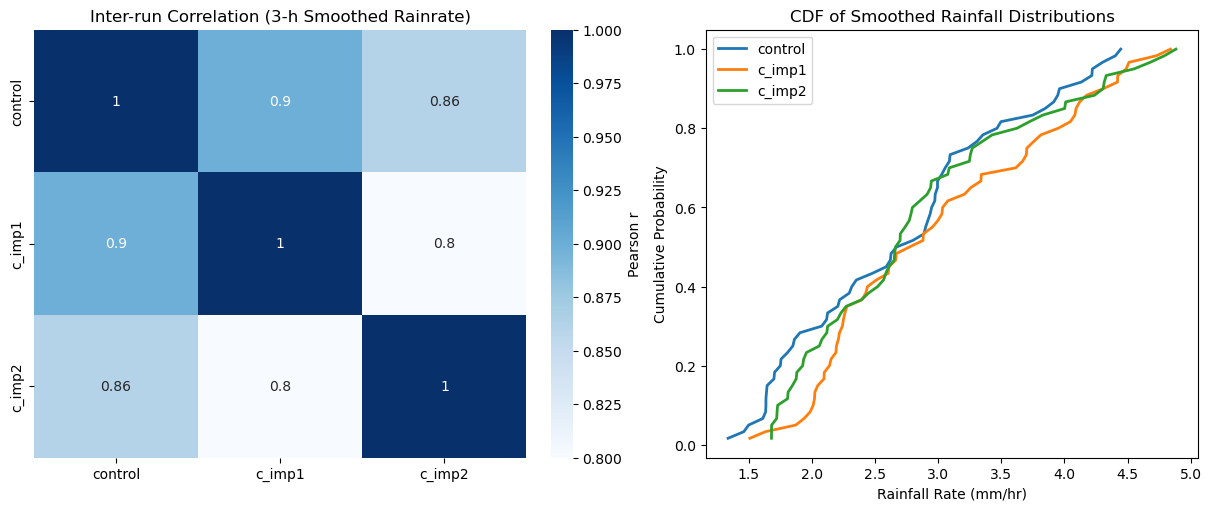

In [ ]:
# From SI document, statistical figure comparing control, c_imp1, and c_imp2 using CDF and correlation heatmap
trackfilesuse = {
    'control': track_file_control,
    'c_imp1': track_file_ctrlimp,
    'c_imp2': track_file_cimp2,
}
directoriesuse = [
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfout.nc',  # ctrl
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/ctrl_imp/output/stitchd02_wrfoutimp.nc',  # cimp
    '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/ctrl_imp/outputnewimp/stitchd02_wrfoutctrlimp2.nc', # cimp2
]

plot_rainrate_similarity(
    runnamelist=['control', 'c_imp1', 'c_imp2'],
    directories=directoriesuse,  # first three for your control set
    trackfiles=trackfilesuse,
    rmax=2,
    mask=True,
    savepath='rainrate_similarity_ctrls_smoothed.png'
)